## Importando bibliotecas e arquivos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# Carregando todos os arquivos
files = [
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]


## Modelagem - Unindo as tabelas e limpando


In [ ]:
# Dicionário para armazenar os DataFrames
data = {}

for file in files:
    name = file.replace('.csv', '')
    try:
        data[name] = pd.read_csv(file)
        print(f"Carregado: {name} | Colunas: {data[name].shape[1]} | Linhas: {data[name].shape[0]}")
    except FileNotFoundError:
        print(f"Aviso: {file} não encontrado no diretório atual.")

# A. Unir Pedidos (Orders) com Clientes (Customers)
df = pd.merge(data['olist_orders_dataset'], data['olist_customers_dataset'], on='customer_id')

# B. Unir com Itens do Pedido (Order Items)
df = pd.merge(df, data['olist_order_items_dataset'], on='order_id')

# C. Unir com Produtos (Products) para ter as categorias
df = pd.merge(df, data['olist_products_dataset'], on='product_id')

# D. Unir com Pagamentos (Payments)
df = pd.merge(df, data['olist_order_payments_dataset'], on='order_id')

# E. Unir com Vendedores (Sellers)
df = pd.merge(df, data['olist_sellers_dataset'], on='seller_id')

# F. Unir com Reviews (Opcional, mas útil para análise de satisfação)
df = pd.merge(df, data['olist_order_reviews_dataset'], on='order_id')

# G. Traduzir nomes de categorias
df = pd.merge(df, data['product_category_name_translation'], on='product_category_name')

# Converter colunas de data para o tipo datetime
date_columns = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Cria de Novas Métricas para Análise
# Tempo de entrega real vs estimado
df['delivery_time_actual'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_time_estimated'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

Carregado: olist_customers_dataset | Colunas: 5 | Linhas: 99441
Carregado: olist_geolocation_dataset | Colunas: 5 | Linhas: 1000163
Carregado: olist_order_items_dataset | Colunas: 7 | Linhas: 112650
Carregado: olist_order_payments_dataset | Colunas: 5 | Linhas: 103886
Carregado: olist_order_reviews_dataset | Colunas: 7 | Linhas: 99224
Carregado: olist_orders_dataset | Colunas: 8 | Linhas: 99441
Carregado: olist_products_dataset | Colunas: 9 | Linhas: 32951
Carregado: olist_sellers_dataset | Colunas: 4 | Linhas: 3095
Carregado: product_category_name_translation | Colunas: 2 | Linhas: 71


In [ ]:
# Varios Status diferentes, pra análise só interessa os 'delivered' que foram os produtos entregues
df['order_status'].value_counts()

,count
order_status,
delivered,113210
shipped,1138
canceled,536
invoiced,358
processing,357
unavailable,7
approved,3


In [ ]:
# Filtra apenas os entregues
df = df[df['order_status'] == 'delivered'].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113210 entries, 0 to 115608
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113210 non-null  object        
 1   customer_id                    113210 non-null  object        
 2   order_status                   113210 non-null  object        
 3   order_purchase_timestamp       113210 non-null  datetime64[ns]
 4   order_approved_at              113196 non-null  datetime64[ns]
 5   order_delivered_carrier_date   113208 non-null  datetime64[ns]
 6   order_delivered_customer_date  113202 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113210 non-null  datetime64[ns]
 8   customer_unique_id             113210 non-null  object        
 9   customer_zip_code_prefix       113210 non-null  int64         
 10  customer_city                  113210 non-null  object        
 11  custo

# **2. Logística e SLA**

Correlação entre atrasos e review_score.

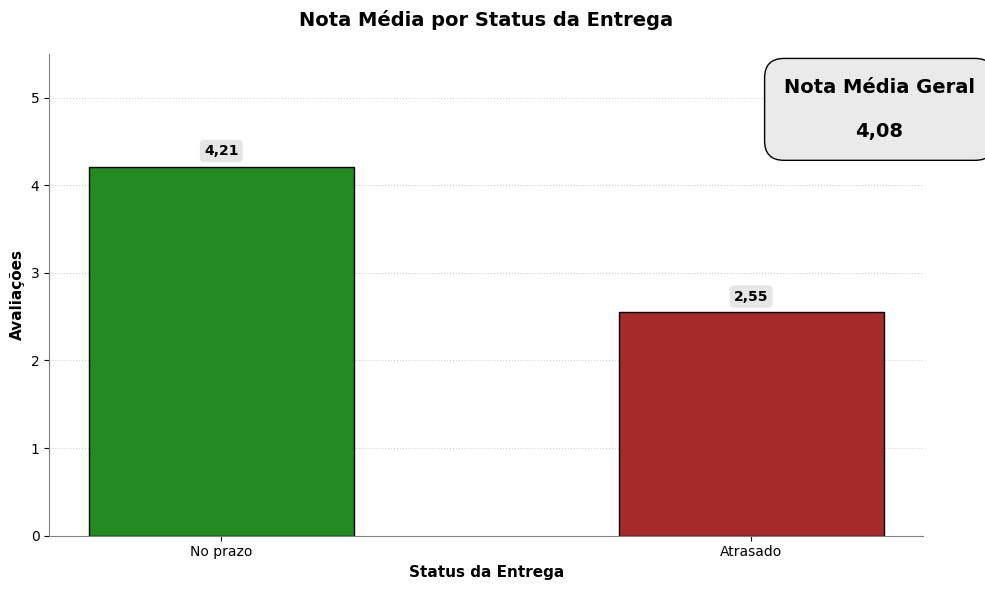

In [ ]:

# Status_Entrega: Se data real > data estimada, "Atrasado", senão "No prazo"
df['Status_Entrega'] = np.where(
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date'],
    'Atrasado',
    'No prazo'
)

# Média por status
df_medias = df.groupby('Status_Entrega')['review_score'].mean().reset_index()

# Ordenando o gráfico
df_medias['Status_Entrega'] = pd.Categorical(df_medias['Status_Entrega'], categories=['No prazo', 'Atrasado'], ordered=True)
df_medias = df_medias.sort_values('Status_Entrega')

# KPI Média Geral
media_geral = df['review_score'].mean()

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

cores = ['#228B22', '#A52A2A']

# Cria as barras
barras = ax.bar(
    df_medias['Status_Entrega'],
    df_medias['review_score'],
    color=cores,
    edgecolor='black',
    width=0.5,
    zorder=3
)

# Formatação
ax.set_ylim(0, 5.5)
ax.set_ylabel('Avaliações', fontweight='bold', fontsize=11)
ax.set_xlabel('Status da Entrega', fontsize=11, fontweight='bold')
ax.set_title('Nota Média por Status da Entrega', fontweight='bold', fontsize=14, pad=20)

# Linhas de grade
ax.yaxis.grid(True, linestyle='dotted', color='lightgray', zorder=0)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')

# Rótulos de Dados
for barra in barras:
    altura = barra.get_height()
    texto_label = f"{altura:.2f}".replace('.', ',')

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.1,
        texto_label,
        ha='center',
        va='bottom',
        fontweight='bold',
        bbox=dict(facecolor='#E0E0E0', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8)
    )

# KPI de Nota Média Geral
texto_kpi = f"Nota Média Geral\n\n{media_geral:.2f}".replace('.', ',')
ax.text(
    0.95, 0.95,
    texto_kpi,
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='#EAEAEA', edgecolor='black', boxstyle='round,pad=1')
)

plt.tight_layout()
plt.show()

Para começar, olhem para este cenário. Nossa nota média geral parece saudável, estacionada em 4,08. Mas as médias mentem. Quando quebramos essa nota pelo cumprimento do SLA, vemos o real problema. Entregas no prazo garantem promotores, com nota 4,21. No entanto, quando falhamos na promessa de entrega, a satisfação desaba para 2,55. O cliente tolera muita coisa no e-commerce, mas a quebra de expectativa do prazo é imperdoável. Nossa primeira missão é estancar essa sangria logística.

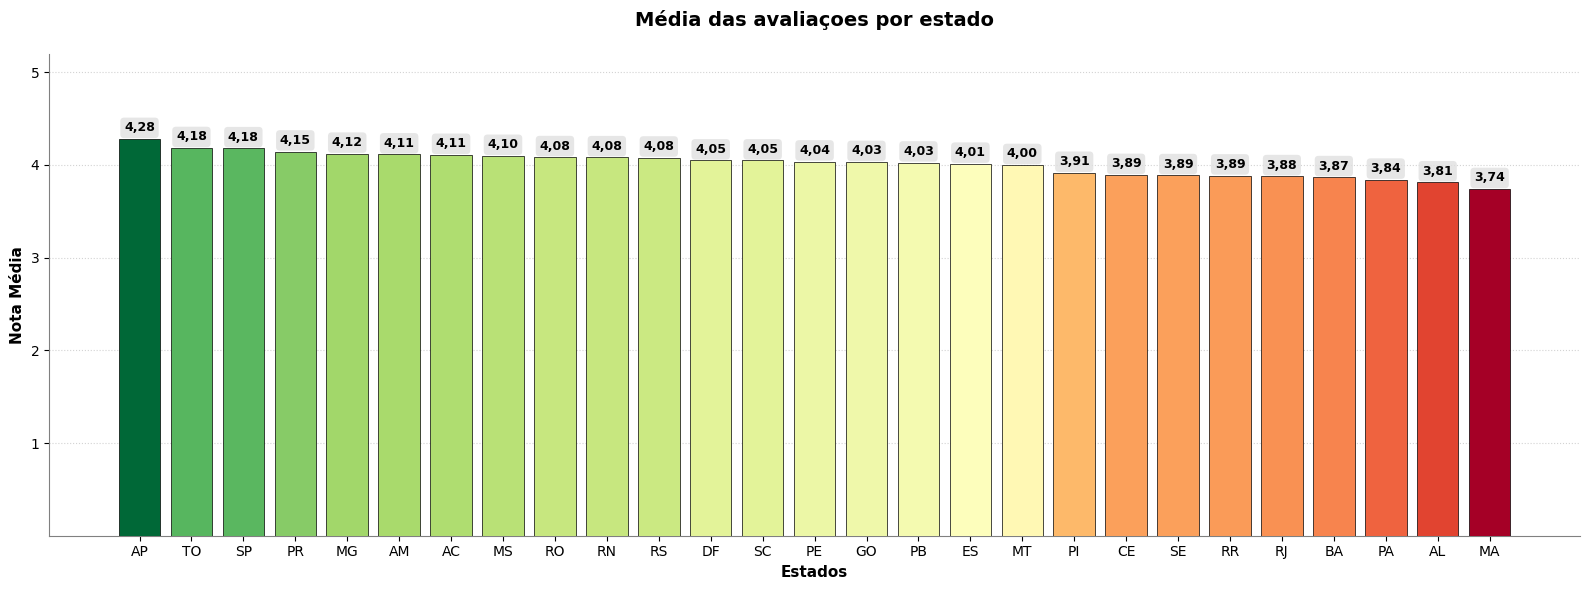

In [ ]:

# Média de review_score por estado
df_estado = df.groupby('customer_state')['review_score'].mean().reset_index()

# Ordenando
df_estado = df_estado.sort_values('review_score', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6), facecolor='white')

# Gradiente de cores
norm = mcolors.Normalize(vmin=df_estado['review_score'].min(), vmax=df_estado['review_score'].max())
cmap = plt.cm.RdYlGn
cores = [cmap(norm(value)) for value in df_estado['review_score']]

# Barras
barras = ax.bar(
    df_estado['customer_state'],
    df_estado['review_score'],
    color=cores,
    edgecolor='black',
    linewidth=0.5,
    zorder=3
)

# Formatação
# Ajustando limites e ticks do eixo Y
ax.set_ylim(0, 5.2) # Limite superior com folga para os rótulos de dados não cortarem
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylabel('Nota Média', fontsize=11, fontweight='bold')
ax.set_xlabel('Estados', fontsize=11, fontweight='bold')
ax.set_title('Média das avaliaçoes por estado', fontweight='bold', fontsize=14, pad=20)

# Linhas de grade
ax.yaxis.grid(True, linestyle='dotted', color='lightgray', zorder=0)

# Remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')

# Rótulos de Dados
for barra in barras:
    altura = barra.get_height()
    texto_label = f"{altura:.2f}".replace('.', ',')

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.05,
        texto_label,
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9,
        bbox=dict(facecolor='#E0E0E0', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8)
    )

plt.tight_layout()
plt.show()

Essa frustração, no entanto, não é distribuída igualmente pelo Brasil. Quando mapeamos as notas por Estado, vemos uma divisão clara no país. O eixo Sul-Sudeste, onde temos nossa maior concentração de malha logística, brilha em verde com notas acima de 4.15. Porém, à medida que a distância aumenta para o Norte e Nordeste, o gráfico sangra. Alagoas e Maranhão amargam notas abaixo de 3.90. Isso nos prova que nosso modelo atual é altamente dependente da proximidade com São Paulo.

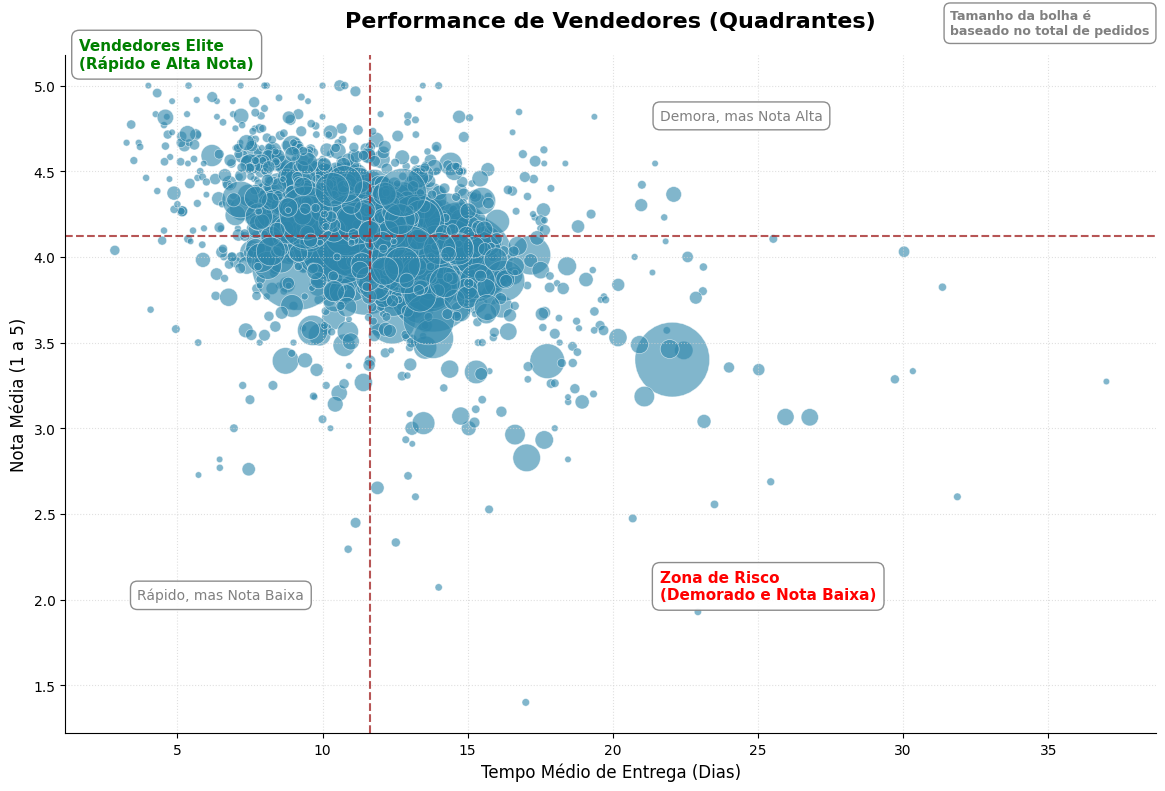

In [ ]:
# Agrupando por seller_id
df_sellers = df.groupby('seller_id').agg(
    Tempo_Medio_Entrega=('delivery_time_actual', 'mean'),
    Nota_Media=('review_score', 'mean'),
    Total_Pedidos=('order_id', 'count')
).reset_index()

# Filtrando sellers com mais de 10 pedidos para análise ter relevância estatística
df_sellers = df_sellers[df_sellers['Total_Pedidos'] > 10]

# Calculando as médias para traçar os quadrantes
media_tempo = df_sellers['Tempo_Medio_Entrega'].mean()
media_nota = df_sellers['Nota_Media'].mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# Criando o scatter plot
# O tamanho da bolha será baseado no Total de Pedidos
scatter = ax.scatter(
    x=df_sellers['Tempo_Medio_Entrega'],
    y=df_sellers['Nota_Media'],
    s=df_sellers['Total_Pedidos'] * 2,
    alpha=0.6,
    c='#2E86AB',
    edgecolors='white',
    linewidth=0.5
)

# Adicionando as linhas dos Quadrantes
ax.axvline(media_tempo, color='#A52A2A', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axhline(media_nota, color='#A52A2A', linestyle='--', linewidth=1.5, alpha=0.8)

# Formatação
ax.set_title('Performance de Vendedores (Quadrantes)', fontweight='bold', fontsize=16, pad=20)
ax.set_xlabel('Tempo Médio de Entrega (Dias)', fontsize=12)
ax.set_ylabel('Nota Média (1 a 5)', fontsize=12)

# Removendo bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', color='lightgray', alpha=0.7)

# Anotações dos Quadrantes
props_bbox = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)

ax.text(media_tempo - 10, 5.1, 'Vendedores Elite\n(Rápido e Alta Nota)', fontsize=11, fontweight='bold', color='green', bbox=props_bbox)
ax.text(media_tempo + 10, 4.8, 'Demora, mas Nota Alta', fontsize=10, color='gray', bbox=props_bbox)
ax.text(media_tempo - 8, 2.0, 'Rápido, mas Nota Baixa', fontsize=10, color='gray', bbox=props_bbox)
ax.text(media_tempo + 10, 2.0, 'Zona de Risco\n(Demorado e Nota Baixa)', fontsize=11, fontweight='bold', color='red', bbox=props_bbox)
ax.text(media_tempo + 20, 5.3, 'Tamanho da bolha é\nbaseado no total de pedidos', fontsize=9, fontweight='bold', color='gray', bbox=props_bbox)

plt.tight_layout()
plt.show()

E de quem é a responsabilidade por essa experiência? Plotamos nossos vendedores nesta matriz de tempo de entrega versus nota média. O tamanho da bolha é o volume de pedidos. Notem que não podemos tratar todos igualmente. No topo à esquerda, temos nossos 'Vendedores Elite': despacham rápido e encantam o cliente. Já na zona de risco, temos vendedores que demoram absurdos 20 a 25 dias e destroem nosso NPS. Precisamos de um programa 'Prime' para reter os melhores e políticas de exclusão para quem prejudica a plataforma.

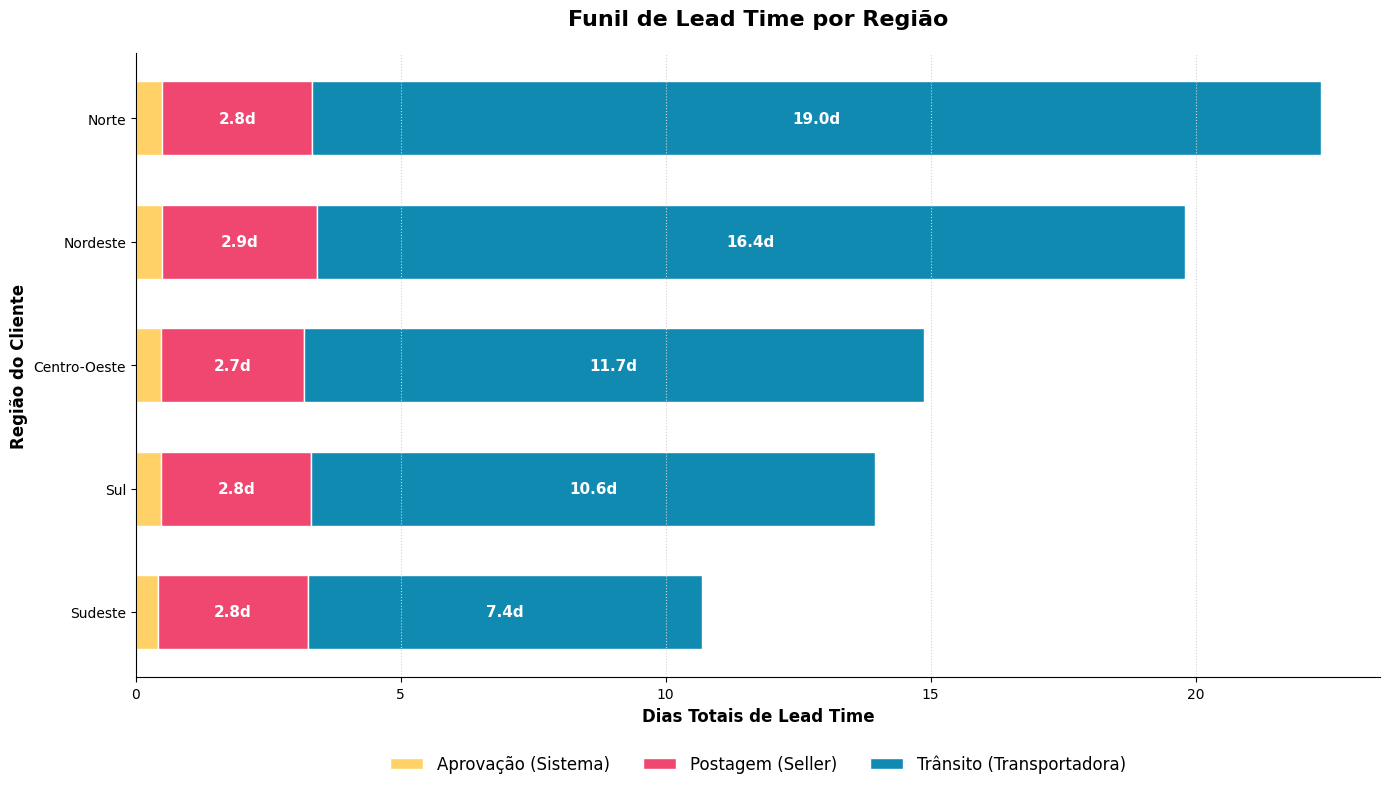

In [ ]:


# Recalculando
df['Tempo_Aprovacao'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
df['Tempo_Postagem'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / (24 * 3600)
df['Tempo_Transito'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / (24 * 3600)

if 'Regiao_Cliente' not in df.columns:
    mapa_regioes = {
        'AM': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'TO': 'Norte', 'RO': 'Norte', 'AC': 'Norte',
        'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste', 'PE': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste', 'AL': 'Nordeste', 'BA': 'Nordeste',
        'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
        'SP': 'Sudeste', 'RJ': 'Sudeste', 'ES': 'Sudeste', 'MG': 'Sudeste',
        'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
    }
    df['Regiao_Cliente'] = df['customer_state'].map(mapa_regioes)

# Agrupando os dados por região
df_funil_regiao = df.groupby('Regiao_Cliente')[['Tempo_Aprovacao', 'Tempo_Postagem', 'Tempo_Transito']].mean().reset_index()

# Criando uma coluna de Total para ordenar o gráfico (do maior lead time para o menor)
df_funil_regiao['Tempo_Total'] = df_funil_regiao['Tempo_Aprovacao'] + df_funil_regiao['Tempo_Postagem'] + df_funil_regiao['Tempo_Transito']
df_funil_regiao = df_funil_regiao.sort_values('Tempo_Total', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

etapas = ['Aprovação (Sistema)', 'Postagem (Seller)', 'Trânsito (Transportadora)']
colunas = ['Tempo_Aprovacao', 'Tempo_Postagem', 'Tempo_Transito']
cores = ['#FFD166', '#EF476F', '#118AB2'] # Amarelo, Rosa, Azul

# Variável (array) para acumular o ponto de início (left) de cada barra
acumulado = np.zeros(len(df_funil_regiao))

for col, cor, etapa in zip(colunas, cores, etapas):
    valores = df_funil_regiao[col].values

    # Criando os pedaços empilhados da barra
    ax.barh(df_funil_regiao['Regiao_Cliente'], valores, left=acumulado, color=cor, edgecolor='white', height=0.6, label=etapa)

    # Adicionando os rótulos de dados dentro de cada pedaço
    for i, (valor, acum) in enumerate(zip(valores, acumulado)):
        if valor > 0.8: # Se a etapa demorar menos de 1 dia, ignora o label visualmente
            ax.text(acum + (valor / 2), i, f"{valor:.1f}d", ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)

    acumulado += valores

# Formatação
ax.set_title('Funil de Lead Time por Região', fontweight='bold', fontsize=16, pad=20)
ax.set_xlabel('Dias Totais de Lead Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Região do Cliente', fontsize=12, fontweight='bold')

# Ajustando a legenda para baixo do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=12)

# Removendo bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle=':', color='lightgray', zorder=0)

plt.tight_layout()
plt.show()

Quando isolamos a culpa do seller da culpa da transportadora, o gargalo fica evidente. Vejam o tempo que o produto passa em trânsito. O tempo de aprovação de pagamento e a separação no estoque do vendedor são praticamente idênticos no Brasil todo. O que esmaga o nosso SLA no Norte e Nordeste é a etapa azul: a malha rodoviária. A Olist não vai conseguir escalar nessas regiões se continuar despachando produtos de São Paulo. Precisamos urgentemente de centros de distribuição regionais.

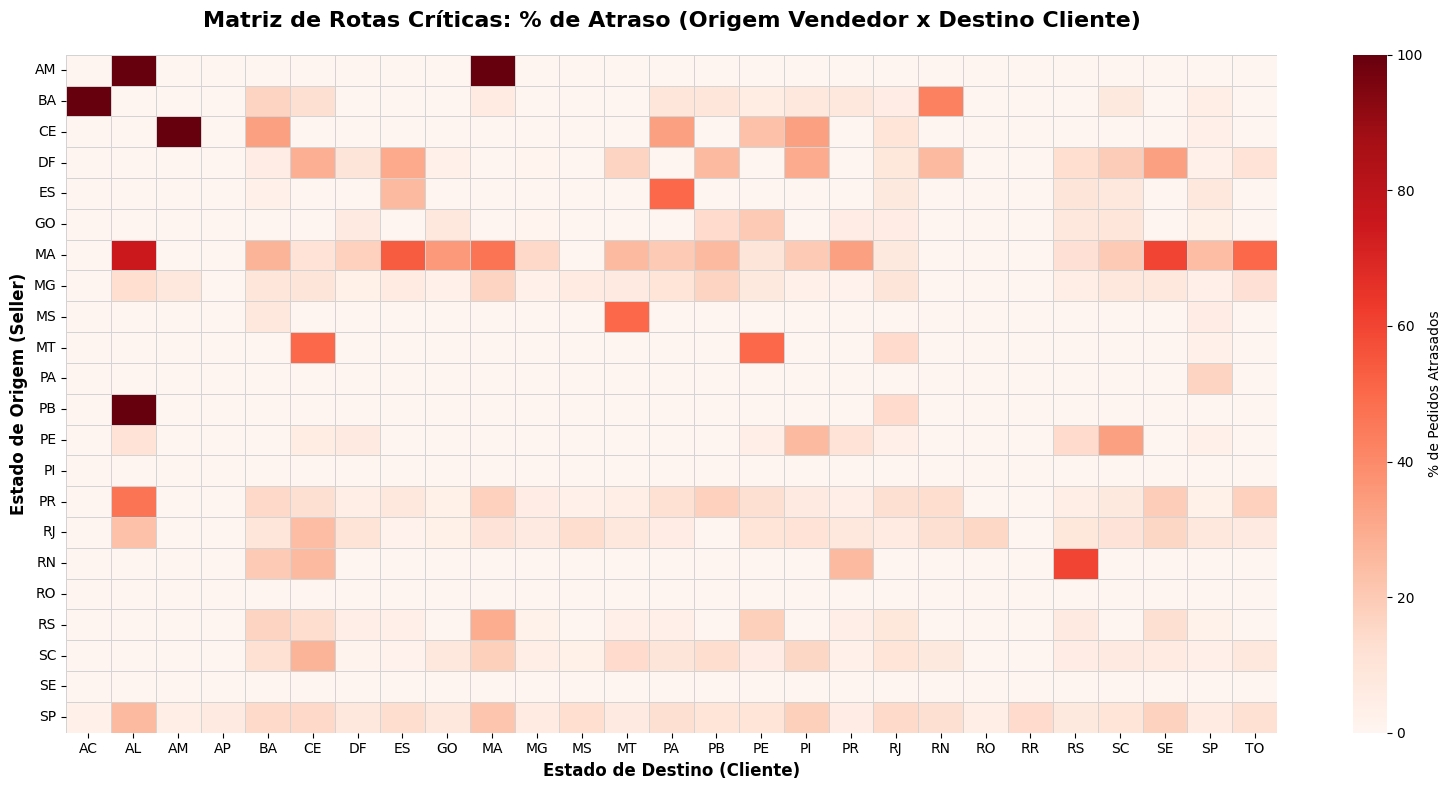

In [ ]:


# Linhas = Estado do Seller, Colunas = Estado do Cliente, Valores = % de Atraso
rotas_pivot = df.pivot_table(
    index='seller_state',
    columns='customer_state',
    values='is_late',
    aggfunc='mean'
) * 100

# Preenchendo valores nulos para o gráfico não quebrar
rotas_pivot = rotas_pivot.fillna(0)

fig, ax = plt.subplots(figsize=(16, 8), facecolor='white')

# Plotando o Heatmap
sns.heatmap(
    rotas_pivot,
    cmap='Reds',
    linewidths=.5,
    linecolor='lightgray',
    cbar_kws={'label': '% de Pedidos Atrasados'},
    ax=ax
)

# Formatação
ax.set_title('Matriz de Rotas Críticas: % de Atraso (Origem Vendedor x Destino Cliente)', fontweight='bold', fontsize=16, pad=20)
ax.set_ylabel('Estado de Origem (Seller)', fontweight='bold', fontsize=12)
ax.set_xlabel('Estado de Destino (Cliente)', fontweight='bold', fontsize=12)

# Ajustando a rotação das labels para melhor leitura
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Se o Funil de Lead Time nos provou que o gargalo está no tempo de trânsito, esta Matriz de Rotas Críticas nos mostra exatamente onde a nossa logística sangra no mapa do Brasil.

Aqui, cruzamos o Estado de origem do vendedor (nas linhas) com o Estado de destino do cliente (nas colunas). A regra é simples: quanto mais escuro o vermelho, mais perto estamos de 100% de quebra de SLA.

Olhem para a linha de São Paulo (SP) lá embaixo. Como a esmagadora maioria dos nossos vendedores está em SP, qualquer venda despachada para o Norte ou Nordeste — como vemos nas colunas de Alagoas, Ceará, Maranhão e Pará — acende o alerta de atraso. Mas o problema se agrava ainda mais nas rotas periféricas: cruzar estados fora do eixo Sul-Sudeste gera esses blocos vermelho-escuro, que são sinônimo de falha garantida na entrega.

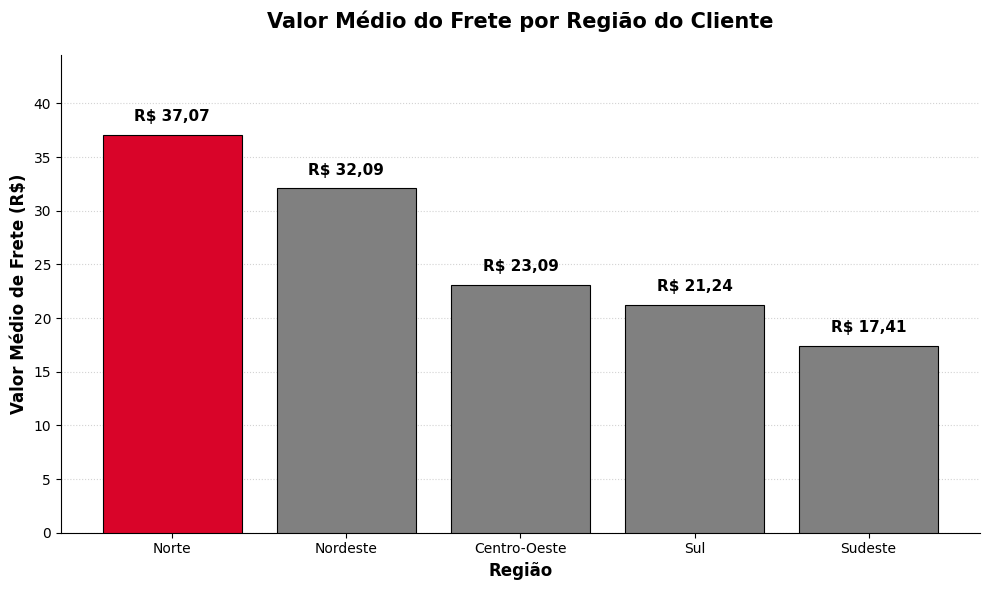

In [ ]:


# Garantindo que a coluna de Região existe (caso você rode esta célula separadamente)
if 'Regiao_Cliente' not in df.columns:
    mapa_regioes = {
        'AM': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'TO': 'Norte', 'RO': 'Norte', 'AC': 'Norte',
        'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste', 'PE': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste', 'AL': 'Nordeste', 'BA': 'Nordeste',
        'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
        'SP': 'Sudeste', 'RJ': 'Sudeste', 'ES': 'Sudeste', 'MG': 'Sudeste',
        'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
    }
    df['Regiao_Cliente'] = df['customer_state'].map(mapa_regioes)

# Calculando a média absoluta do valor do frete por região
df_frete_regiao = df.groupby('Regiao_Cliente')['freight_value'].mean().reset_index()

# Ordenando decrescente
df_frete_regiao = df_frete_regiao.sort_values('freight_value', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Destacando a região mais cara com vermelho e as demais em cinza
cores = ['#D90429' if i == 0 else 'grey' for i in range(len(df_frete_regiao))]

barras = ax.bar(
    df_frete_regiao['Regiao_Cliente'],
    df_frete_regiao['freight_value'],
    color=cores,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

# Formatação
ax.set_title('Valor Médio do Frete por Região do Cliente', fontweight='bold', fontsize=15, pad=20)
ax.set_ylabel('Valor Médio de Frete (R$)', fontsize=12, fontweight='bold')
ax.set_xlabel('Região', fontsize=12,fontweight='bold')

# Ajustando o eixo Y para não cortar os números em cima das barras
ax.set_ylim(0, df_frete_regiao['freight_value'].max() * 1.2)

# Removendo bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', color='lightgray', zorder=0)

# Rótulos de Dados (Adicionando o "R$" em cima das barras)
for barra in barras:
    altura = barra.get_height()
    texto_label = f"R$ {altura:.2f}".replace('.', ',')

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1,
        texto_label,
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.tight_layout()
plt.show()

Além da performance do vendedor, temos uma barreira geográfica brutal: o custo logístico. Observem a discrepância do valor médio de frete. Enquanto no Sudeste o cliente paga cerca de R$ 17, no Norte esse valor salta para mais de R$ 37, e no Nordeste para R$ 32. Nossa malha logística atual, altamente concentrada em São Paulo, está punindo o consumidor dessas regiões, inviabilizando a compra de produtos de menor ticket e travando nossa expansão nacional.

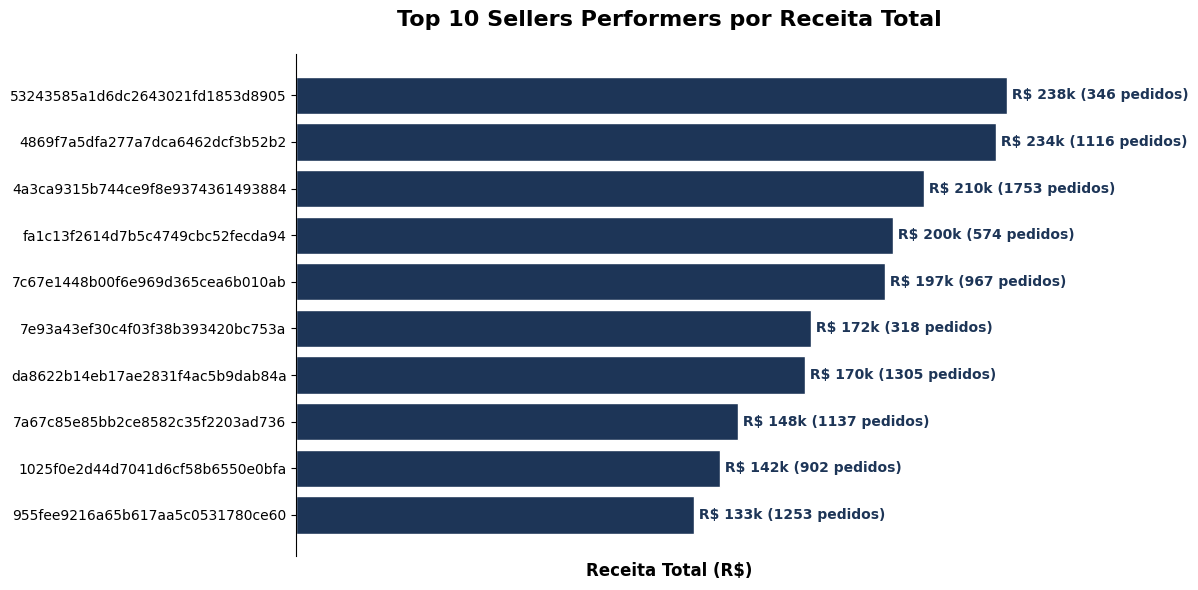

In [ ]:

# Agrupando receita por vendedor
df_sellers = df.groupby('seller_id').agg(
    Receita_Total=('price', 'sum'),
    Qtd_Pedidos=('order_id', 'nunique')
).reset_index()

# Top 10 em Receita
top_10_sellers = df_sellers.nlargest(10, 'Receita_Total').sort_values('Receita_Total', ascending=True)


fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

# Gráfico de barras
barras = ax.barh(
    top_10_sellers['seller_id'],
    top_10_sellers['Receita_Total'],
    color='#1D3557',
    edgecolor='white'
)

# Formatação Título e label
ax.set_title('Top 10 Sellers Performers por Receita Total', fontweight='bold', fontsize=16, pad=20)
ax.set_xlabel('Receita Total (R$)', fontsize=12, fontweight='bold')

# Formatando para moeda
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1000:.0f}k'))

# Rótulos de Dados nas barras (mostrando também a quantidade de pedidos)
for i, barra in enumerate(barras):
    largura = barra.get_width()
    qtd_pedidos = top_10_sellers.iloc[i]['Qtd_Pedidos']

    texto = f" R$ {largura/1000:.0f}k ({qtd_pedidos} pedidos)"
    ax.text(
        largura,
        barra.get_y() + barra.get_height()/2,
        texto,
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1D3557'
    )

# Remove bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_ticks([])

plt.tight_layout()
plt.show()

Quando olhamos para a inteligência comercial, vemos uma regra de Pareto muito clara. Estes são os nossos Top 10 vendedores. Apenas o primeiro colocado já trouxe mais de R$ 238 mil em receita em 346 pedidos. O sucesso financeiro da Olist está fortemente ancorado em um grupo muito seleto de parceiros. Qualquer estratégia de crescimento deve envolver Account Managers (Gerentes de Conta) dedicados exclusivamente a blindar e escalar esses top performers.

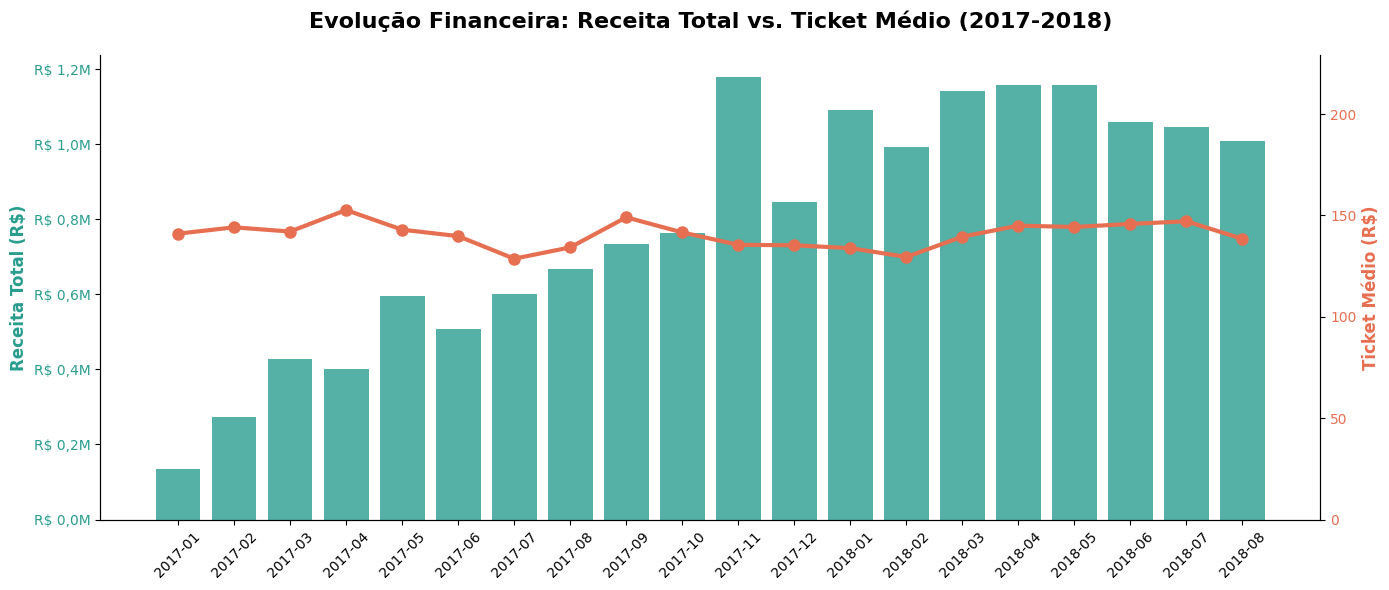

In [ ]:


# Receita Total = Preço do Produto + Frete
df['Receita_Total'] = df['price'] + df['freight_value']

# Ano_Mes em formato de string
df['Ano_Mes'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agrupando os dados por mês
df_financeiro = df.groupby('Ano_Mes').agg(
    Pedidos=('order_id', 'nunique'), # Contagem de pedidos únicos
    Receita=('Receita_Total', 'sum'),
    Ticket_Medio=('Receita_Total', 'mean')
).reset_index()

# Removendo meses com dados parciais
df_financeiro = df_financeiro[(df_financeiro['Ano_Mes'] >= '2017-01') & (df_financeiro['Ano_Mes'] <= '2018-08')]

fig, ax1 = plt.subplots(figsize=(14, 6), facecolor='white')

# Eixo 1: Receita Total
ax1.bar(df_financeiro['Ano_Mes'], df_financeiro['Receita'], color='#2A9D8F', alpha=0.8, label='Receita Total')
ax1.set_ylabel('Receita Total (R$)', color='#2A9D8F', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2A9D8F')
plt.xticks(rotation=45)

# Formatando o eixo Y da receita para M (Milhões)
formatter = ticker.FuncFormatter(lambda x, p: f'R$ {x/1000000:.1f}M'.replace('.', ','))
ax1.yaxis.set_major_formatter(formatter)

# Eixo 2: Ticket Médio
ax2 = ax1.twinx()
ax2.plot(df_financeiro['Ano_Mes'], df_financeiro['Ticket_Medio'], color='#E76F51', marker='o', linewidth=3, markersize=8, label='Ticket Médio')
ax2.set_ylabel('Ticket Médio (R$)', color='#E76F51', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E76F51')
ax2.set_ylim(0, df_financeiro['Ticket_Medio'].max() * 1.5)

# Formatação
ax1.set_title('Evolução Financeira: Receita Total vs. Ticket Médio (2017-2018)', fontweight='bold', fontsize=16, pad=20)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

E como a plataforma cresceu entre 2017 e 2018? Tivemos um salto excelente na Receita Total, com meses ultrapassando a marca de 1 milhão de reais, como vemos nas barras verdes. O marketing fez seu trabalho trazendo volume. No entanto, olhem para a linha laranja: nosso Ticket Médio está estagnado, variando sempre na faixa de R$ 130 a R$ 150. Isso significa que estamos trazendo mais clientes, mas não estamos conseguindo fazer com que eles comprem produtos mais caros ou coloquem mais itens no carrinho (cross-sell).

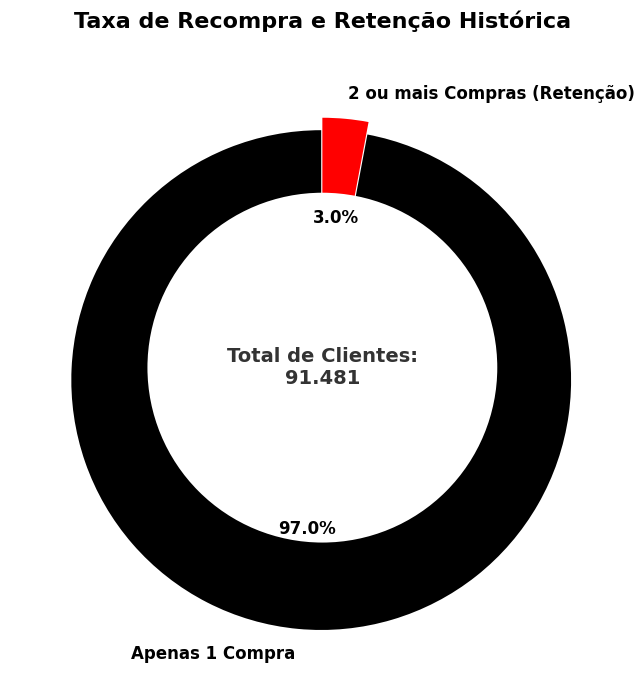

In [ ]:

# Contando quantos pedidos cada cliente unico fez
df_clientes = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_clientes.columns = ['customer_unique_id', 'Qtd_Compras']

# Classificando os clientes
df_clientes['Tipo_Cliente'] = np.where(df_clientes['Qtd_Compras'] == 1, 'Apenas 1 Compra', '2 ou mais Compras (Retenção)')

# Contando o total de clientes em cada categoria
dados_retencao = df_clientes['Tipo_Cliente'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

cores = ['black', 'red']
explode = (0.05, 0)

# Cria o gráfico de pizza
wedges, texts, autotexts = ax.pie(
    dados_retencao,
    labels=dados_retencao.index,
    autopct='%1.1f%%', # Formato da porcentagem
    startangle=90,
    colors=cores,
    explode=explode,
    textprops=dict(color="black", fontsize=12, fontweight='bold')
)

# Transformando a pizza em uma rosca
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centro_circulo)

# Adiciona o texto
total_clientes = len(df_clientes)
plt.text(0, 0, f'Total de Clientes:\n{total_clientes:,}'.replace(',', '.'),
         ha='center', va='center', fontsize=14, fontweight='bold', color='#333333')

# Formatação título
ax.set_title('Taxa de Recompra e Retenção Histórica', fontweight='bold', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

E aqui chegamos ao nosso maior gargalo estratégico. Todo aquele esforço de marketing, logística e vendas deságua neste gráfico. De uma base de mais de 91 mil clientes, absurdos 97% compraram apenas uma vez. Estamos operando como um 'balde furado'. Gastamos dinheiro para adquirir o cliente, mas a entrega atrasada e o frete caro fazem com que ele não volte. O nosso Lifetime Value (LTV) é praticamente inexistente.

Em resumo, os dados são claros. Nossa recomendação estratégica passa por três pilares: Primeiro, criar hubs logísticos no Nordeste para baratear frete e cortar tempo de trânsito. Segundo, ranquear vendedores, dando o 'Buy Box' (destaque) apenas para os rápidos e bem avaliados. E terceiro, implementar inteligência de dados no cálculo do SLA, parando de fazer promessas de entrega irreais. Consertando a casa, a recompra virá naturalmente.
